# 🌸 DecodeLabs AI Internship - Project 2

## Data Classification Using Artificial Intelligence

### 👤 Name: Vishwas Parashar
### 🎓 College: GLA University, Mathura
### 💻 Algorithm: K-Nearest Neighbors (KNN)
### 📊 Dataset: Iris Dataset
### 🛠️ Platform: Google Colab

In [2]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [3]:
# Load Iris Dataset

iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["Species"] = y

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
# Dataset Information

print("Shape :", df.shape)
print("\nColumns :")
print(df.columns)

print("\nInformation :")
df.info()

print("\nStatistical Summary :")
display(df.describe())

Shape : (150, 5)

Columns :
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'Species'],
      dtype='object')

Information :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Statistical Summary :


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
# Missing Values

print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64


In [6]:
# Target Classes

print("Flower Classes:")
print(iris.target_names)

print("\nNumber of samples in each class:")
print(df["Species"].value_counts())

Flower Classes:
['setosa' 'versicolor' 'virginica']

Number of samples in each class:
Species
0    50
1    50
2    50
Name: count, dtype: int64


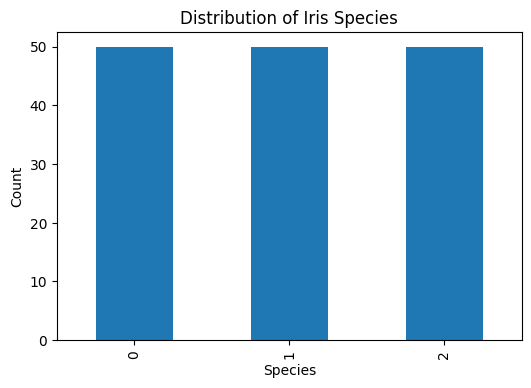

In [7]:
# Species Distribution

df["Species"].value_counts().plot(kind="bar", figsize=(6,4))

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

In [8]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (120, 4)
Testing Data : (30, 4)


In [9]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


In [10]:
# Train KNN Model

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [11]:
# Prediction

y_pred = model.predict(X_test)

print("Predictions Generated Successfully!")

Predictions Generated Successfully!


In [12]:
# Accuracy Score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy :", round(accuracy*100,2), "%")

Model Accuracy : 93.33 %


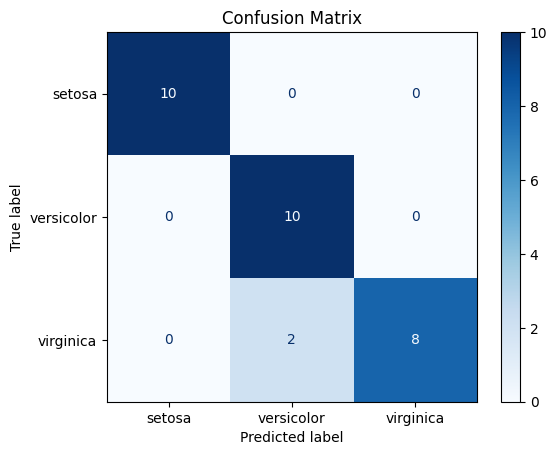

In [13]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=iris.target_names)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [14]:
# Classification Report

print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [15]:
# Test on New Flower

sample = [[5.1, 3.5, 1.4, 0.2]]

sample = scaler.transform(sample)

prediction = model.predict(sample)

print("Predicted Flower :", iris.target_names[prediction][0])

Predicted Flower : setosa
